In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import json
from datetime import datetime

# Configuration
pd.set_option('display.max_columns', None)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: mps


## Load database

### Load raw damage dataset

In [37]:
df_damage = pd.read_csv("../../../development/database/cars_damage_dataset/data_damage.csv")
df_damage = df_damage.drop(columns=["Unnamed: 0"])
df_damage['image_path'] = df_damage['image'].apply(lambda x: f"../../../development/database/cars_damage_dataset/{x}")

print(f"Damage dataset: {len(df_damage)} images")
print("]nClass distribution:")
print(df_damage['classes'].value_counts())
df_damage.head()

Damage dataset: 1594 images
]nClass distribution:
classes
unknown           549
door_dent         192
bumper_scratch    164
door_scratch      154
glass_shatter     137
tail_lamp         136
head_lamp         133
bumper_dent       129
Name: count, dtype: int64


,image,classes,image_path
0,image/0.jpeg,unknown,../../../development/database/cars_damage_data...
1,image/1.jpeg,head_lamp,../../../development/database/cars_damage_data...
2,image/2.jpeg,door_scratch,../../../development/database/cars_damage_data...
3,image/3.jpeg,head_lamp,../../../development/database/cars_damage_data...
4,image/4.jpeg,unknown,../../../development/database/cars_damage_data...


### Load training & validation damage dataset

In [38]:
training_dir = Path("../../../development/database/cars_damage_dataset/cars_image_crash_dataset_addition/training")
validation_dir = Path("../../../development/database/cars_damage_dataset/cars_image_crash_dataset_addition/validation")

def load_additional_data(directory, source):
    data = []
    valid_extensions = {".jpg", ".jpeg", ".JPG", ".JPEG"}
    
    if not directory.exists():
        print(f"Warning: Directory '{directory}' not found.")
        return pd.DataFrame(data)

    for class_dir in directory.iterdir():
        if class_dir.is_dir():
            # Iterate through directory and filter by image extensions
            for img_path in class_dir.iterdir():
                if img_path.is_file() and img_path.suffix in valid_extensions:
                    data.append({
                        "image": str(img_path),
                        "classes": class_dir.name,
                        "source": source,
                        "image_path": str(img_path)
                    })
                    
    return pd.DataFrame(data)

# Load dataframes
df_train_add = load_additional_data(training_dir, "additional_training")
df_val_add = load_additional_data(validation_dir, "additional_validation")

# Check results
print(f"Additional training images: {len(df_train_add)}")
print(f"Additional validation images: {len(df_val_add)}")
print("\nAdditional training classes breakdown:")
print(df_train_add['classes'].value_counts())

Additional training images: 1383
Additional validation images: 248

Additional training classes breakdown:
classes
03-severe      468
02-moderate    463
01-minor       452
Name: count, dtype: int64


In [ ]:
if 'source' not in df_damage.columns:
    df_damage['source'] = 'raw_damage_dataset'

# Combine All images data
df_all_images = pd.concat([
    df_damage[['image', 'classes', 'source', 'image_path']],
    df_train_add,
    df_val_add
], ignore_index=True)

print(f"Total combined images: {len(df_all_images)}")
print("\nSource distribution:")
print(df_all_images['source'].value_counts())
print("\nClass distribution (combined):")
print(df_all_images['classes'].value_counts())

Total combined images: 3225

Source distribution:
source
raw_damage_dataset       1594
additional_training      1383
additional_validation     248
Name: count, dtype: int64

Class distribution (combined):
classes
03-severe         559
unknown           549
02-moderate       538
01-minor          534
door_dent         192
bumper_scratch    164
door_scratch      154
glass_shatter     137
tail_lamp         136
head_lamp         133
bumper_dent       129
Name: count, dtype: int64


## Feature engineering

In [41]:
df_all_images['classes'] = df_all_images['classes'].str.lower()
df_all_images['classes'] = df_all_images['classes'].replace({
    'unknown': 'no_damage',
    'unkown': 'no_damage',
    'no damage': 'no_damage',
})

severity_mapping = {
    'no_damage': 0,
    'door_scratch': 1,
    'bumper_scrape': 1,
    'dent': 1,
    'head_lamp': 2,
    'broken_headlight': 2
}

df_all_images['severity'] = df_all_images['classes'].map(severity_mapping)
df_all_images = df_all_images.dropna(subset=['severity'])

print("Class distribution after cleaning:")
print(df_all_images['classes'].value_counts())
print("\nSeverity distribution:")
print(df_all_images['severity'].value_counts())

# Save severity mapping
with open('severity_mapping.json', 'w') as f:
    json.dump(severity_mapping, f, indent=2)

Class distribution after cleaning:
classes
no_damage       549
door_scratch    154
head_lamp       133
Name: count, dtype: int64

Severity distribution:
severity
0.0    549
1.0    154
2.0    133
Name: count, dtype: int64


### Load car sales database

In [42]:
df_car = pd.read_parquet("../../../development/database/car_sales_prediction_sales.parquet")
print(f"Total sales records: {len(df_car)}")
df_car = df_car[['car_id', 'date', 'customer_name', 'dealer_name', 'company', 'model', 'discount']]
print(f"\nDataFrame shape: {df_car.shape}")
df_car.head()

Total sales records: 23905

DataFrame shape: (23905, 7)


,car_id,date,customer_name,dealer_name,company,model,discount
0,C_CND_000001,2022-01-02,Geraldine,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,0.05
1,C_CND_000002,2022-01-02,Gia,C & M Motors Inc,Dodge,Durango,0.10
2,C_CND_000003,2022-01-02,Gianna,Capitol KIA,Cadillac,Eldorado,0.02
3,C_CND_000004,2022-01-02,Giselle,Chrysler of Tri-Cities,Toyota,Celica,0.50
4,C_CND_000005,2022-01-02,Grace,Chrysler Plymouth,Acura,TL,0.10


## Data visualization

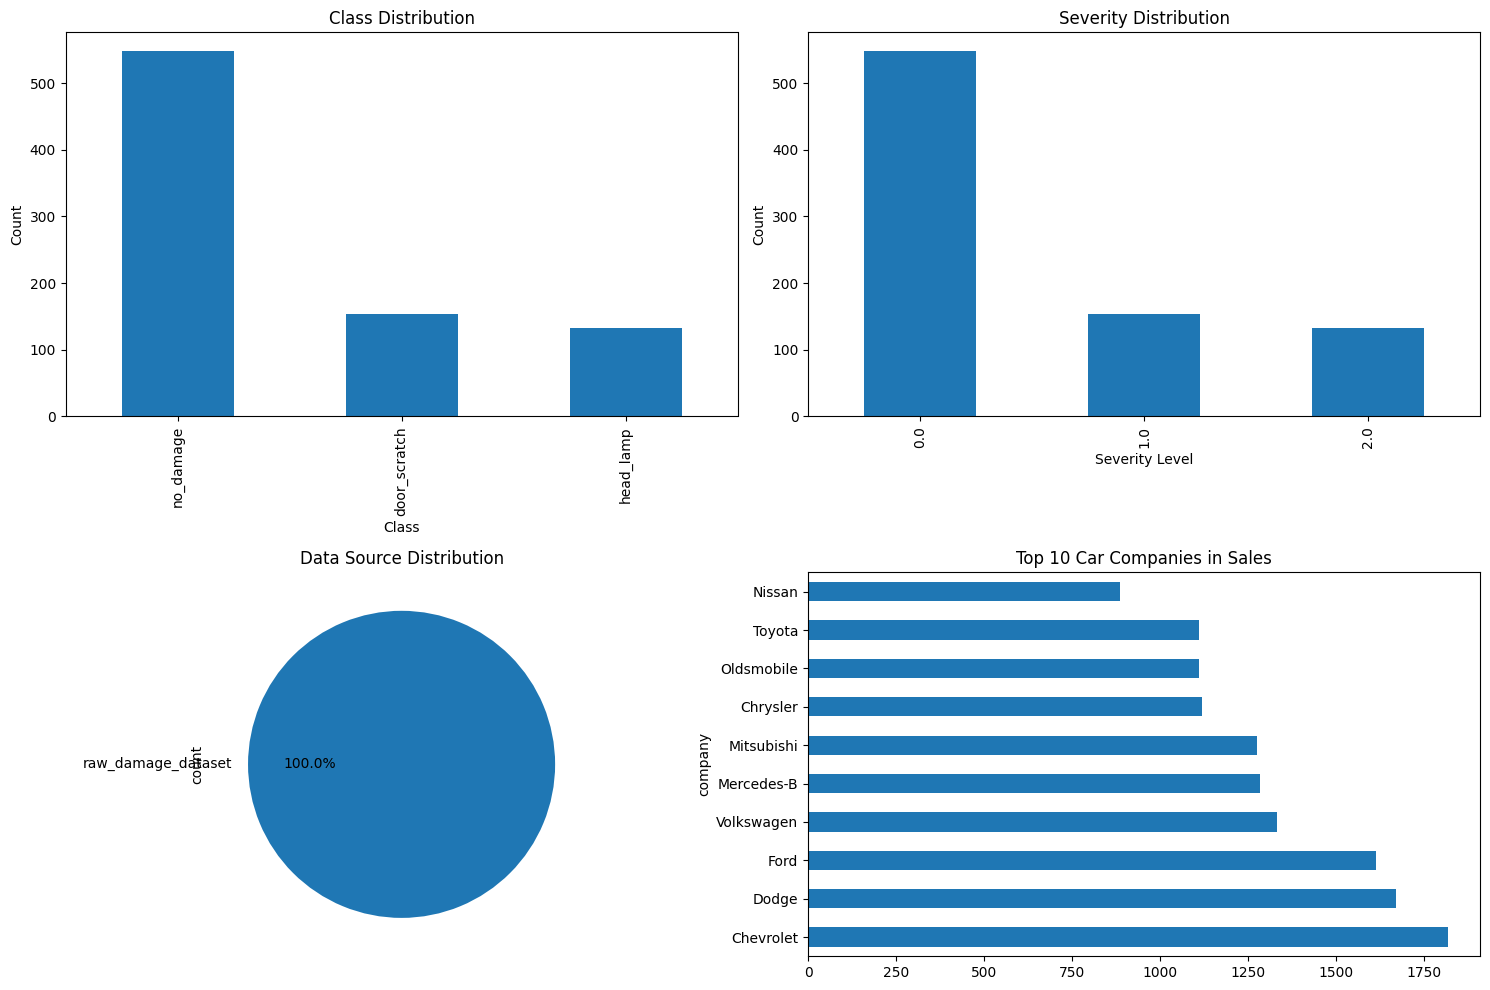

In [ ]:
# CELL 7: EDA - Data Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Class distribution
df_all_images['classes'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_xlabel('Class')
axes[0,0].set_ylabel('Count')

# Severity distribution
df_all_images['severity'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Severity Distribution')
axes[0,1].set_xlabel('Severity Level')
axes[0,1].set_ylabel('Count')

# Source distribution
df_all_images['source'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Data Source Distribution')

# Car sales top companies
df_car['company'].value_counts().head(10).plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('Top 10 Car Companies in Sales')

plt.tight_layout()
#plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

## Split data into X and y

In [44]:
X = df_all_images['image_path'].values
y = df_all_images['classes'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())
print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts())

Training samples: 668
Validation samples: 168

Training class distribution:
no_damage       439
door_scratch    123
head_lamp       106
Name: count, dtype: int64

Validation class distribution:
no_damage       110
door_scratch     31
head_lamp        27
Name: count, dtype: int64


## Data label encoding

In [48]:
# CELL 9: Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

class_mapping = {cls: int(idx) for idx, cls in enumerate(label_encoder.classes_)}
print("Class mapping:")
for cls, idx in class_mapping.items():
    print(f"  {cls}: {idx}")

# Save class mapping
with open('class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)

Class mapping:
  door_scratch: 0
  head_lamp: 1
  no_damage: 2


## Albumentations Transforms

In [50]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Transpose(p=0.5),
    A.OneOf([
        A.MotionBlur(p=0.2),
        A.MedianBlur(blur_limit=3, p=0.1),
        A.Blur(blur_limit=3, p=0.1),
    ], p=0.3),
    A.OneOf([
        A.OpticalDistortion(p=0.3),
        A.GridDistortion(p=0.1),
    ], p=0.3),
    A.OneOf([
        A.CLAHE(clip_limit=2),
        A.Sharpen(),
        A.Emboss(),
        A.RandomBrightnessContrast(),
    ], p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

## Dataset class

In [56]:
class CarDamageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        image = np.array(image)
        label = self.labels[idx]

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, torch.tensor(label, dtype=torch.long)

## DataLoaders

In [58]:
train_dataset = CarDamageDataset(X_train, y_train_encoded, transform=train_transform)
val_dataset = CarDamageDataset(X_val, y_val_encoded, transform=train_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Save datasets for later use
torch.save({
    'train_dataset': train_dataset,
    'val_dataset': val_dataset,
    'train_loader': train_loader,
    'val_loader': val_loader,
    'label_encoder': label_encoder,
    'class_mapping': class_mapping,
    'severity_mapping': severity_mapping
}, 'data_preparation_outputs.pth')

print("Data preparation complete! Outputs saved.")

Training batches: 21
Validation batches: 6
Data preparation complete! Outputs saved.
